In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
df.shape

(48895, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
#handeling missing values
df['name'].fillna('Unknown',inplace=True)
df['host_name'].fillna('Unknown',inplace=True)
df['reviews_per_month'].fillna(0,inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,0.0,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,0.0,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,0.0,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,0.0,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,0.0,1,23


#EDA

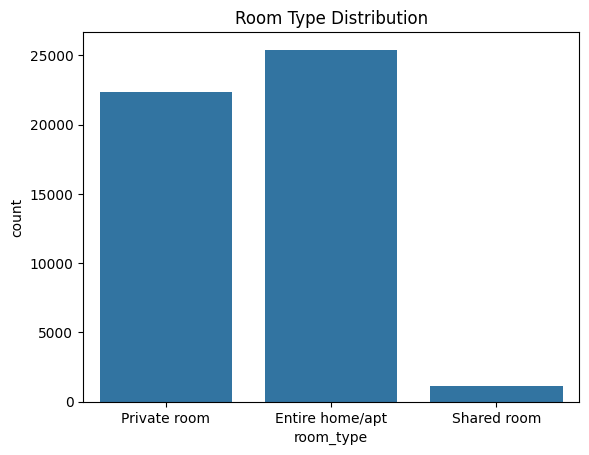

In [ ]:
#Room type distribution
sns.countplot(data=df,x='room_type')
plt.title("Room Type Distribution")
plt.show()

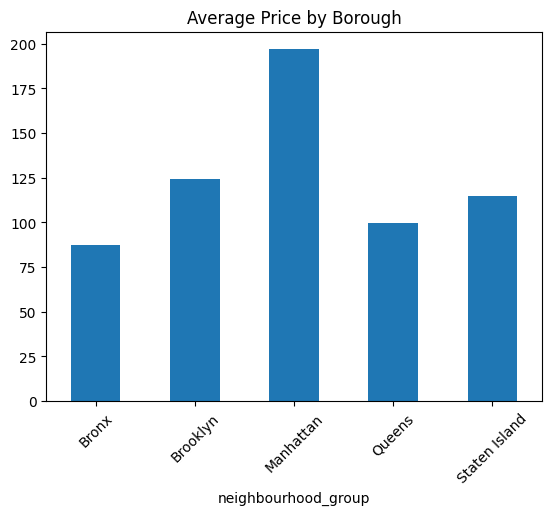

In [ ]:
#Most Expensive Areas
top_price = df.groupby('neighbourhood_group')['price'].mean()

top_price.plot(kind='bar')
plt.xticks(rotation=45)

plt.title("Average Price by Borough")
plt.show()

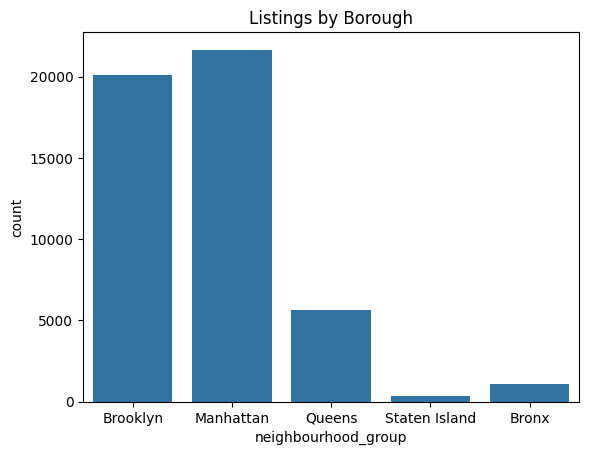

In [ ]:
#Most Popular Areas
sns.countplot(data=df, x='neighbourhood_group')

plt.title("Listings by Borough")
plt.show()

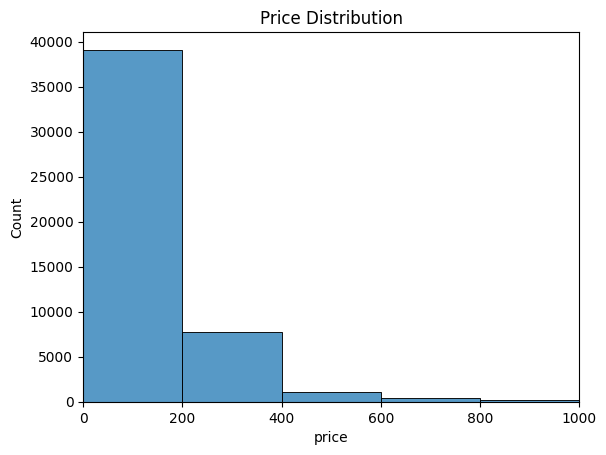

In [ ]:
#Price Distribution
sns.histplot(df['price'], bins=50)

plt.xlim(0,1000)
plt.title("Price Distribution")

plt.show()

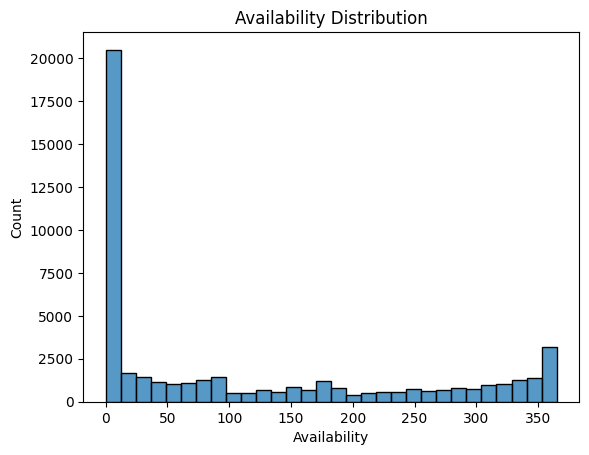

In [ ]:
#Availability Analysis
sns.histplot(df['availability_365'])
plt.xlabel("Availability")
plt.ylabel("Count")

plt.title("Availability Distribution")
plt.show()

In [ ]:
#Top Host
df['host_name'].value_counts().head(10)

,count
host_name,
Michael,417
David,403
Sonder (NYC),327
John,294
Alex,279
Blueground,232
Sarah,227
Daniel,226
Jessica,205


In [ ]:
#Most Reviewed Listings
df.sort_values(by='number_of_reviews', ascending=False)[
    ['name','host_name','number_of_reviews']
].head(10)

,name,host_name,number_of_reviews
11759,Room near JFK Queen Bed,Dona,629
2031,Great Bedroom in Manhattan,Jj,607
2030,Beautiful Bedroom in Manhattan,Jj,597
2015,Private Bedroom in Manhattan,Jj,594
13495,Room Near JFK Twin Beds,Dona,576
10623,Steps away from Laguardia airport,Maya,543
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,Carol,540
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,Danielle,510
4870,Private brownstone studio Brooklyn,Asa,488
471,LG Private Room/Family Friendly,Wanda,480


<Axes: >

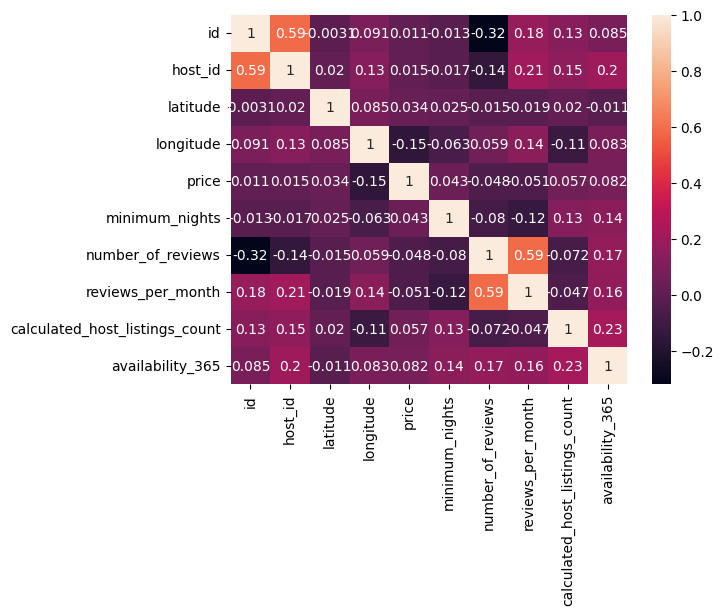

In [ ]:
#Correlation Analysis
sns.heatmap(df.corr(numeric_only=True), annot=True)

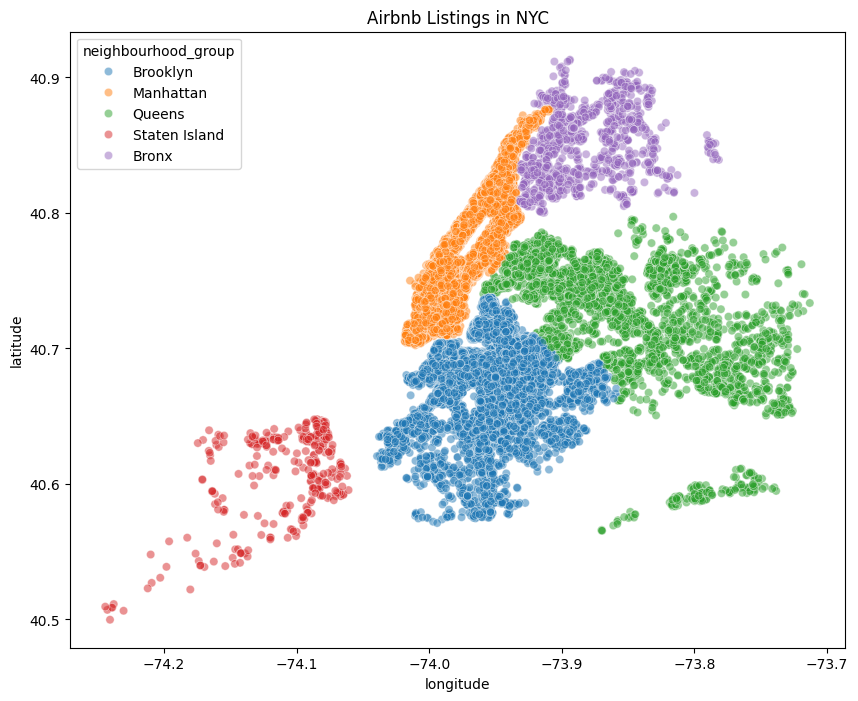

In [ ]:
#Geographic Analysis
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    alpha=0.5
)

plt.title("Airbnb Listings in NYC")
plt.show()

##Feature Engineering

In [ ]:
df['price_category'] = pd.cut(
    df['price'],
    bins=[0,100,300,1000],
    labels=['Low','Medium','High']
)

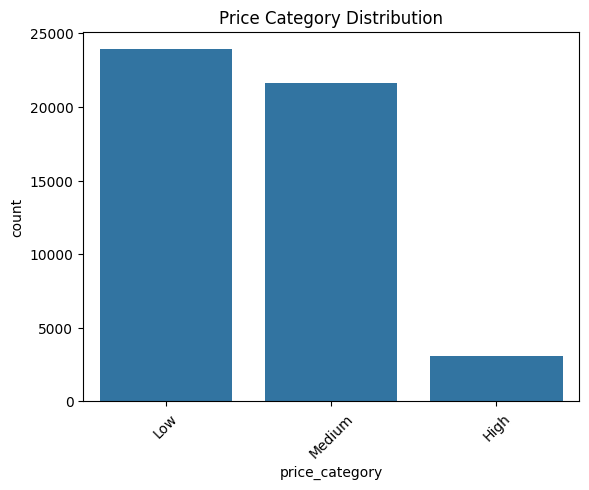

In [ ]:
#Price category
sns.countplot(data=df,x='price_category')
plt.title("Price Category Distribution")
plt.xticks(rotation=45)
plt.show()

##K-Mean Clustering

In [ ]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


In [ ]:
#Outlier removed
df = df[df['price'] < 1000]

<Axes: >

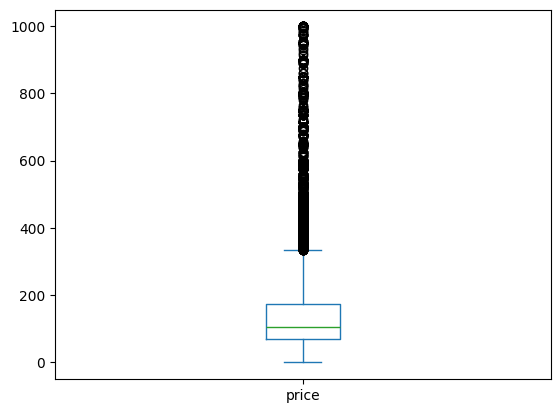

In [ ]:
df['price'].plot(kind='box')

In [ ]:
le=LabelEncoder()
df['room_type_encoded']=le.fit_transform(df['room_type'])

In [ ]:
#Features
X = df[
    [
        'latitude',
        'longitude',
        'price',
        'availability_365',
        'minimum_nights',
        'room_type_encoded'
    ]
]

In [ ]:
#Feature Scaling
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [ ]:
#Find Best Number of Clusters (Elbow Method)
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

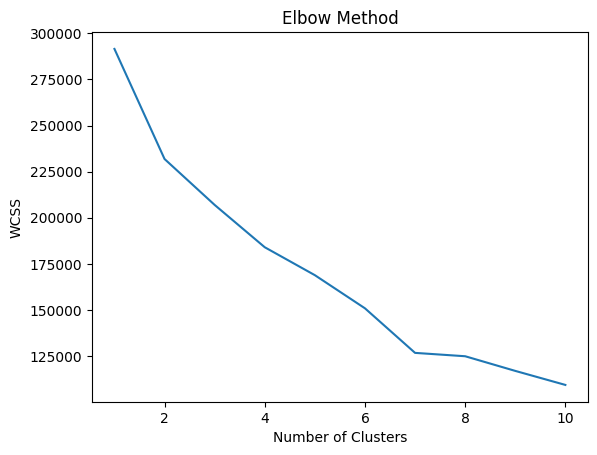

In [ ]:
plt.plot(range(1,11), wcss)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(X_scaled)

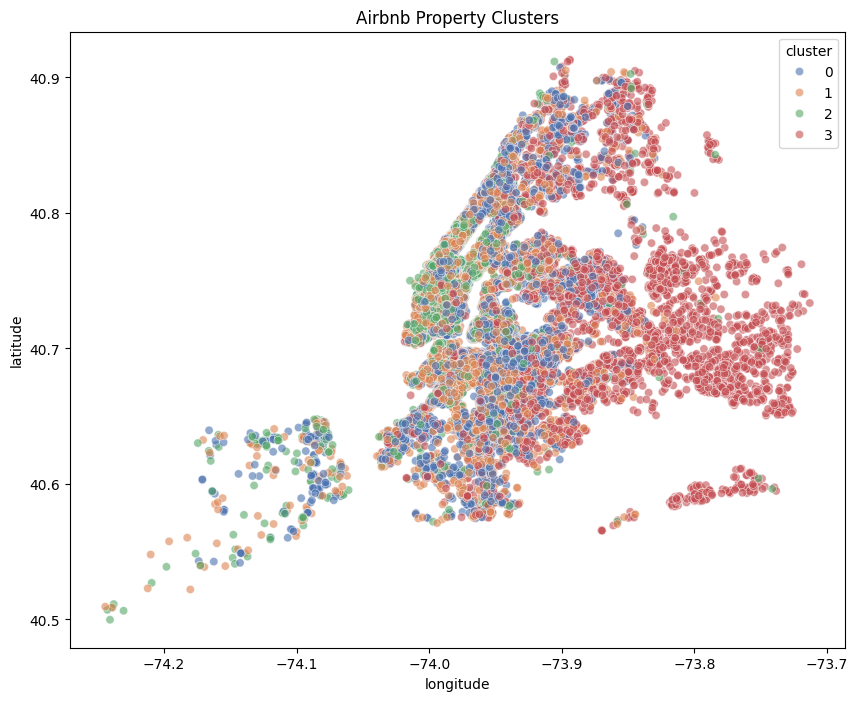

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='deep',
    alpha=0.6
)

plt.title("Airbnb Property Clusters")

plt.show()

| Cluster | Meaning                    |
| ------- | -------------------------- |
| 0       | Luxury Manhattan homes     |
| 1       | Budget Brooklyn rooms      |
| 2       | Shared tourist rooms       |
| 3       | Long-term affordable stays |

